## Conceptual Understanding: XAI Fundamentals for Multimodal Models

**Why Explainability Matters:**
Deep learning models like BLIP are often "black boxes" — they produce accurate
captions, but it's unclear *why* they generated a specific word or phrase. For
multimodal models specifically, explainability helps us:
1. **Debug failures** — e.g., understand why BLIP described a horse race as
   "a clear blue sky" (seen in Week 2 Day 5).
2. **Build trust** — especially important in sensitive applications (medical
   imaging captioning, accessibility tools for the visually impaired).
3. **Detect bias** — check if the model relies on spurious correlations (e.g.,
   background context) rather than the actual subject.

**Local vs. Global Explanations:**
- **Local explanation**: Explains a single prediction. E.g., "For this specific
  image, which pixels most influenced the word 'dog' in the caption?"
- **Global explanation**: Explains overall model behavior across many examples.
  E.g., "Does this model consistently rely on background color to identify
  certain animals?"
- This week focuses primarily on **local explanations** — analyzing individual
  curated examples in depth.

**Attribution Methods (Overview):**
- **Grad-CAM**: Uses gradients flowing into the final convolutional/attention
  layers of the vision encoder to produce a heatmap showing which image regions
  most influenced the output.
- **SHAP (SHapley Additive exPlanations)**: Based on game theory; assigns each
  input feature (e.g., each word/token) a contribution value toward the final
  prediction.
- **LIME (Local Interpretable Model-agnostic Explanations)**: Approximates the
  complex model locally with a simple, interpretable model to explain individual
  predictions.
- **Attention visualization**: Since BLIP uses cross-attention between image
  patches and generated words, we can directly visualize which image regions the
  decoder attended to for each generated word.

**This Week's Plan:**
- Day 1: Select representative examples (mix of good/poor captions) from Week 2.
- Day 2: Apply Grad-CAM on the vision encoder to see *where* the model looked.
- Day 3: Apply SHAP/LIME and attention alignment to see *which words/tokens*
  mattered most in generation.

In [1]:
!pip install -q transformers accelerate pillow kaggle

import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_32feae0c86a02acb063a9c9873d0afeb'
!mkdir -p ~/.kaggle
!echo '{"KAGGLE_API_TOKEN":"'$KAGGLE_API_TOKEN'"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d adityajn105/flickr8k
!unzip -oq flickr8k.zip -d flickr8k_data
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:12<00:00, 86.3MB/s]

Dataset ready!


In [2]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import pandas as pd
import random

device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

image_folder = "flickr8k_data/Images"
caption_file = "flickr8k_data/captions.txt"
captions_df = pd.read_csv(caption_file)

print("BLIP model loaded!")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BLIP model loaded!


In [3]:
!pip install -q nltk
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tqdm import tqdm

smoothie = SmoothingFunction().method4

# Ek bada pool select karein jisme se best/worst chunenge
random.seed(42)
all_images = os.listdir(image_folder)
candidate_pool = random.sample(all_images, 60)  # 60 images ka pool, isme se 12-15 select karenge

def generate_caption(image_path):
    raw_image = Image.open(image_path).convert("RGB")
    inputs = processor(raw_image, return_tensors="pt").to(device)
    out = model.generate(**inputs, num_beams=5, max_new_tokens=30)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

pool_results = []
for img_name in tqdm(candidate_pool, desc="Generating & scoring"):
    img_path = os.path.join(image_folder, img_name)
    pred_caption = generate_caption(img_path)
    human_caps = captions_df[captions_df['image'] == img_name]['caption'].tolist()
    refs = [ref.split() for ref in human_caps]
    score = sentence_bleu(refs, pred_caption.split(), smoothing_function=smoothie)
    pool_results.append({
        "image": img_name,
        "blip_caption": pred_caption,
        "human_captions": human_caps,
        "bleu_score": score
    })

pool_df = pd.DataFrame(pool_results)
pool_df = pool_df.sort_values("bleu_score", ascending=False)
print("Done! Score range:", pool_df['bleu_score'].min(), "to", pool_df['bleu_score'].max())

Generating & scoring: 100%|██████████| 60/60 [05:19<00:00,  5.32s/it]

Done! Score range: 0.02079484472761028 to 0.7788007830714049


In [4]:
# Top 7-8 (good captions) aur bottom 7 (poor captions) select karein
good_examples = pool_df.head(8)   # highest BLEU scores
poor_examples = pool_df.tail(7)   # lowest BLEU scores

curated_df = pd.concat([good_examples, poor_examples]).reset_index(drop=True)
curated_df["quality_label"] = ["good"] * len(good_examples) + ["poor"] * len(poor_examples)

print(f"Total curated examples: {len(curated_df)}")
print("\n--- GOOD EXAMPLES ---")
for _, row in good_examples.iterrows():
    print(f"{row['image']} (BLEU={row['bleu_score']:.3f}): {row['blip_caption']}")

print("\n--- POOR EXAMPLES ---")
for _, row in poor_examples.iterrows():
    print(f"{row['image']} (BLEU={row['bleu_score']:.3f}): {row['blip_caption']}")

Total curated examples: 15

--- GOOD EXAMPLES ---
2931254547_e97c6d0d63.jpg (BLEU=0.779): a crowd of people
226531363_33ac01d931.jpg (BLEU=0.765): a dog running in the snow on a sunny day
3678098428_40c1b74cc2.jpg (BLEU=0.763): a man wearing a black tank top
252504549_135b0db5a3.jpg (BLEU=0.726): a small dog playing with a ball on the beach
2979914158_5906470b8f.jpg (BLEU=0.691): a young girl is swinging on a swing
3482974845_db4f16befa.jpg (BLEU=0.643): two dogs running on the beach
2629445284_83390e83af.jpg (BLEU=0.615): a dog jumping over an obstacle in a field
2443512473_6f5a22eb42.jpg (BLEU=0.548): a black and white dog

--- POOR EXAMPLES ---
1187435567_18173c148b.jpg (BLEU=0.053): the dog is black and brown
3701544312_b2e4e9813d.jpg (BLEU=0.045): the woman is holding a stick
3536561454_e75993d903.jpg (BLEU=0.040): a man riding a skateboard down a street
3726168984_1fa2c8965b.jpg (BLEU=0.038): two dogs playing in the grass
3627076769_3b71e73018.jpg (BLEU=0.038): two women sitting 

In [5]:
import shutil
import json

os.makedirs("data/xai_examples", exist_ok=True)
os.makedirs("data/xai_examples/images", exist_ok=True)

curated_records = []
for _, row in curated_df.iterrows():
    img_name = row["image"]
    src_path = os.path.join(image_folder, img_name)
    dst_path = os.path.join("data/xai_examples/images", img_name)
    shutil.copy(src_path, dst_path)

    curated_records.append({
        "image": img_name,
        "blip_caption": row["blip_caption"],
        "human_captions": row["human_captions"],
        "bleu_score": float(row["bleu_score"]),
        "quality_label": row["quality_label"]
    })

with open("data/xai_examples/curated_examples.json", "w") as f:
    json.dump(curated_records, f, indent=2)

print(f"Saved {len(curated_records)} images to data/xai_examples/images/")
print("Metadata saved to data/xai_examples/curated_examples.json")

Saved 15 images to data/xai_examples/images/
Metadata saved to data/xai_examples/curated_examples.json


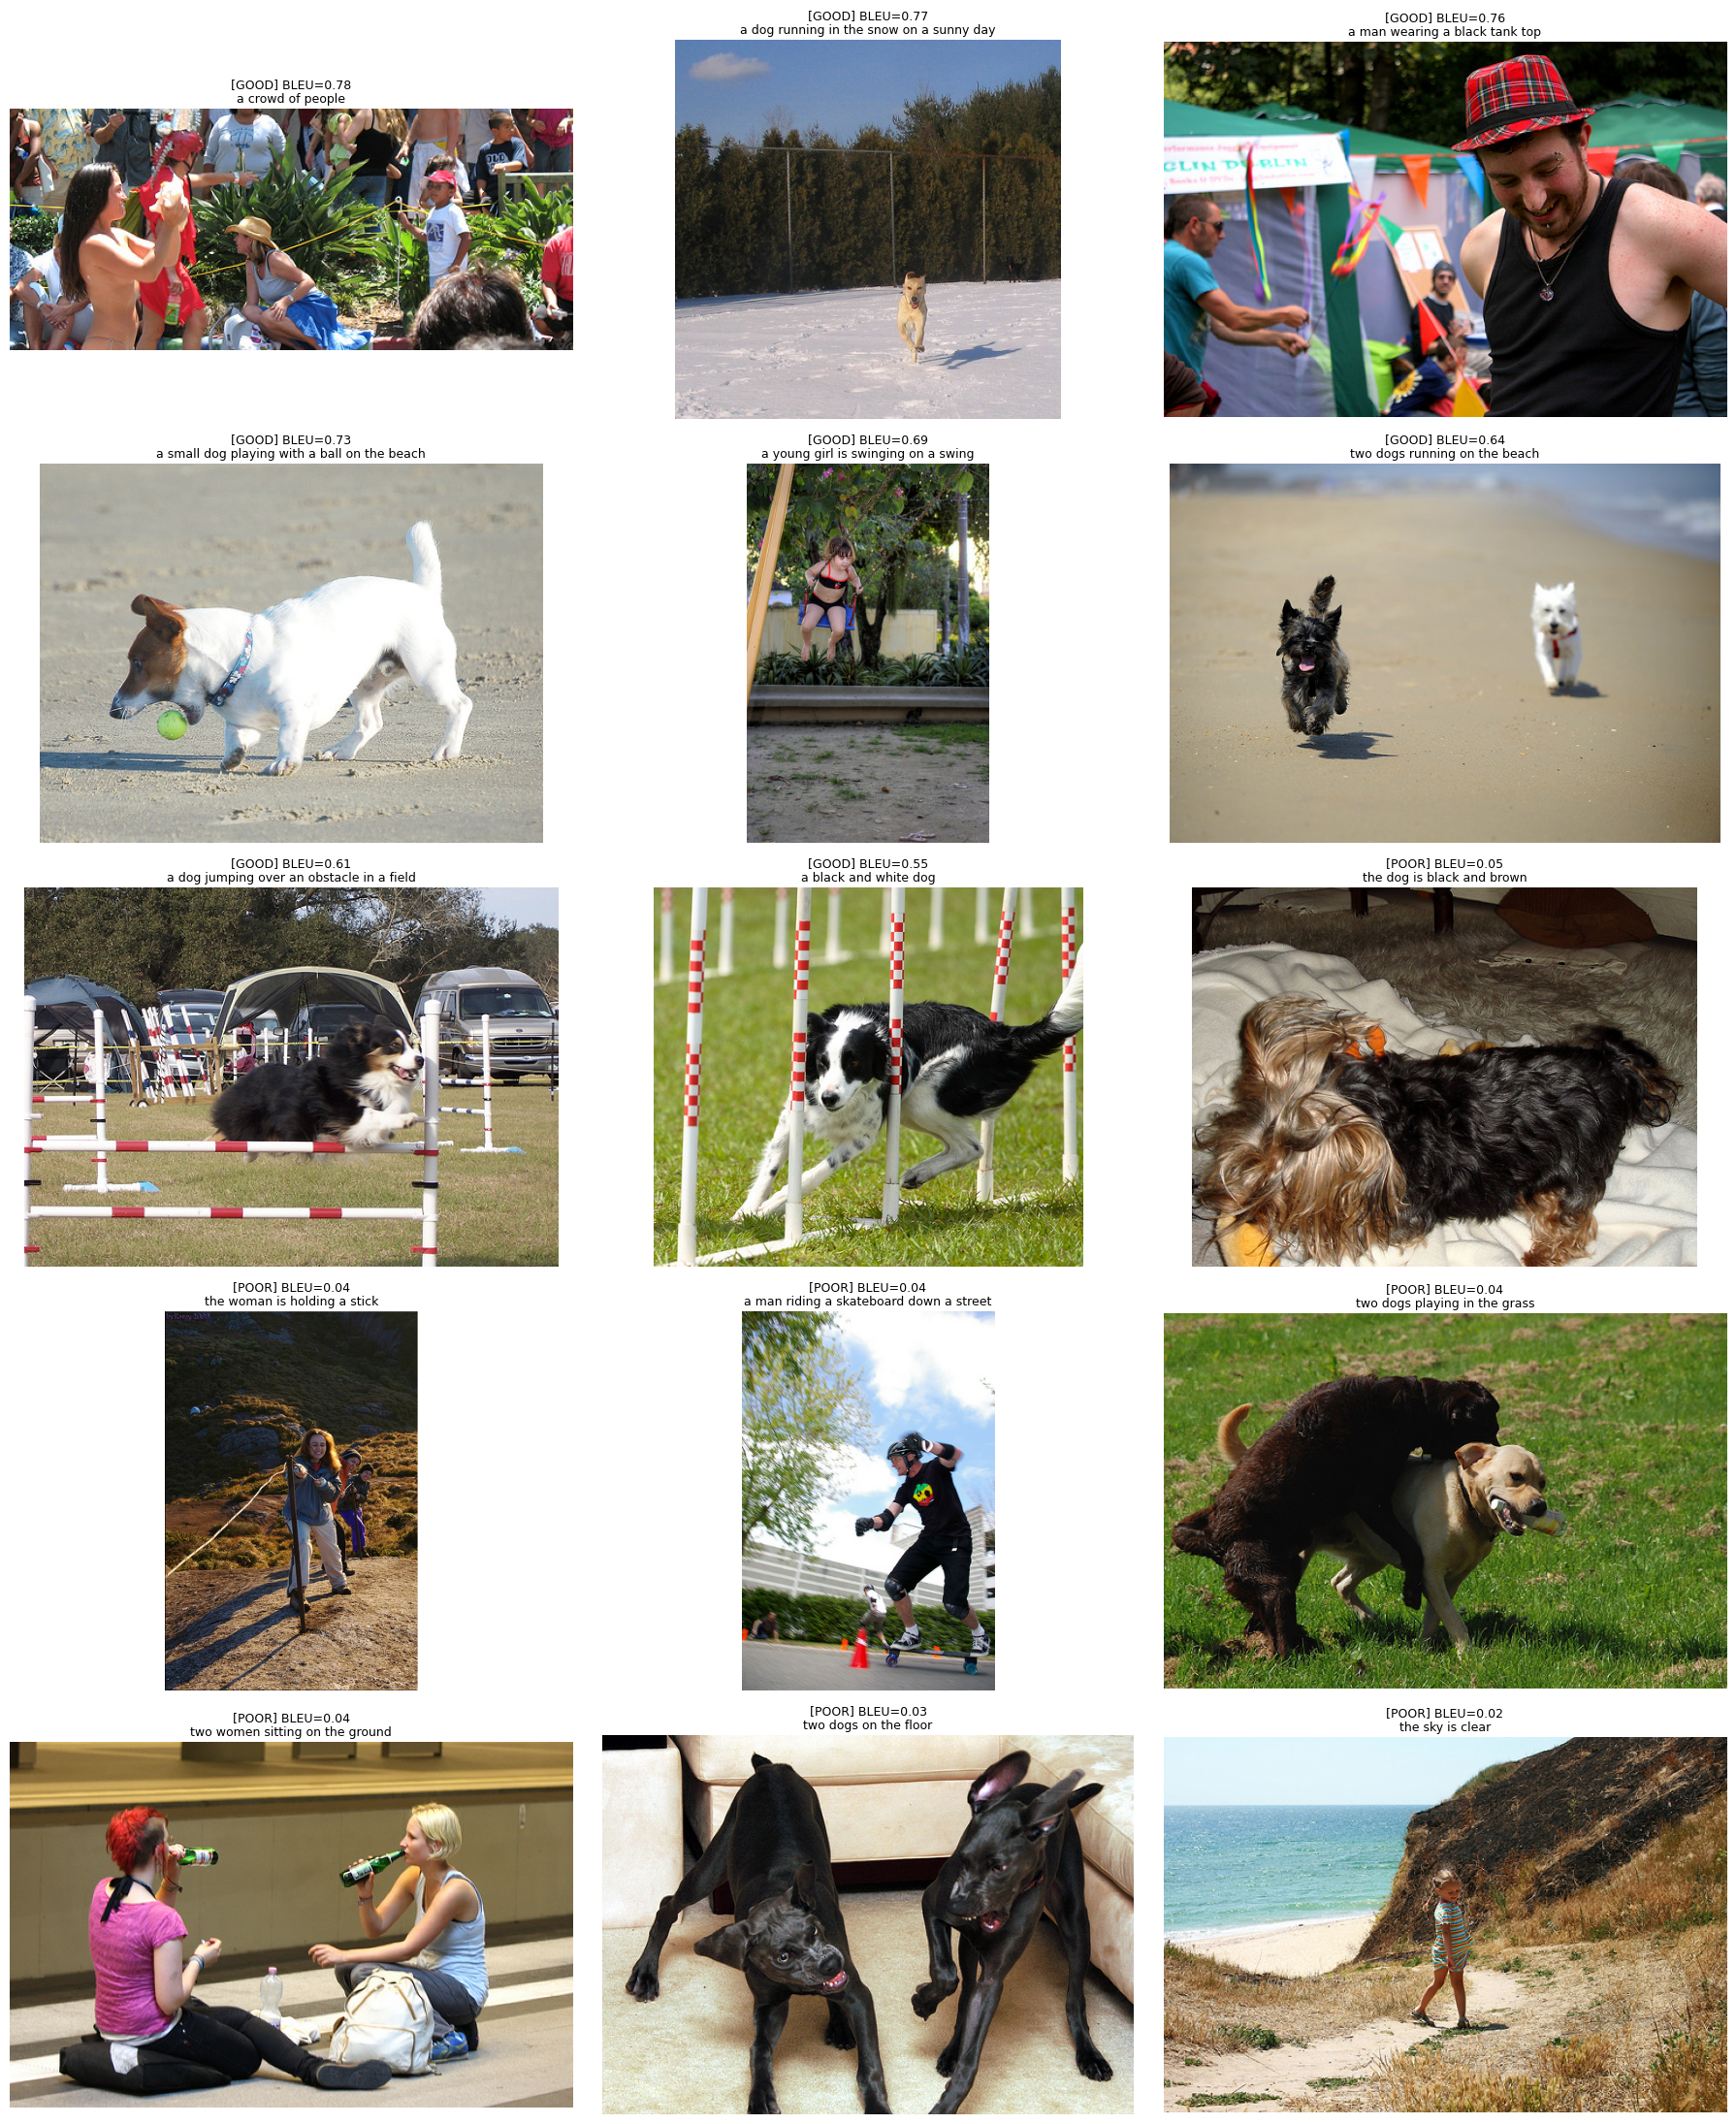

Overview image saved!


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for idx, (_, row) in enumerate(curated_df.iterrows()):
    img_path = os.path.join("data/xai_examples/images", row["image"])
    image = Image.open(img_path).convert("RGB")
    axes[idx].imshow(image)
    label = row["quality_label"].upper()
    axes[idx].set_title(f"[{label}] BLEU={row['bleu_score']:.2f}\n{row['blip_caption']}",
                          fontsize=9, wrap=True)
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig("data/xai_examples/curated_examples_overview.png", dpi=100)
plt.show()

print("Overview image saved!")

In [7]:
!zip -r xai_examples_backup.zip data/xai_examples
from google.colab import files
files.download('xai_examples_backup.zip')

  adding: data/xai_examples/ (stored 0%)
  adding: data/xai_examples/curated_examples.json (deflated 71%)
  adding: data/xai_examples/curated_examples_overview.png (deflated 0%)
  adding: data/xai_examples/images/ (stored 0%)
  adding: data/xai_examples/images/3482974845_db4f16befa.jpg (deflated 1%)
  adding: data/xai_examples/images/2979914158_5906470b8f.jpg (deflated 0%)
  adding: data/xai_examples/images/3701544312_b2e4e9813d.jpg (deflated 0%)
  adding: data/xai_examples/images/252504549_135b0db5a3.jpg (deflated 1%)
  adding: data/xai_examples/images/3678098428_40c1b74cc2.jpg (deflated 0%)
  adding: data/xai_examples/images/3726168984_1fa2c8965b.jpg (deflated 0%)
  adding: data/xai_examples/images/2931254547_e97c6d0d63.jpg (deflated 0%)
  adding: data/xai_examples/images/3627076769_3b71e73018.jpg (deflated 0%)
  adding: data/xai_examples/images/1187435567_18173c148b.jpg (deflated 0%)
  adding: data/xai_examples/images/2443512473_6f5a22eb42.jpg (deflated 0%)
  adding: data/xai_exampl

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>